In [4]:
# Cell 1: Setup and imports
import os

os.environ['KERAS_BACKEND'] = 'torch'  # You can change to 'jax' or 'torch' if preferred

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

Keras version: 3.9.0
Keras backend: tensorflow


Ladataan datasetti, käyttäen r eli read mode, jotta saadaan kaikki merkit oikein. Varmistetaan että käytetään utf-8 enkoodia, jotta saadaan kaikki merkit oikein. Säilytetään datasetti muuttujaan text.

In [5]:
# Cell 2: Load and prepare text data
# Load the Kalevala text
with open('../datasets/seitsemänveljestä.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()  #.lower()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 627004 characters
First 100 characters: ENSIMMÄINEN LUKU


Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella
rinteellä, liki


In [6]:
# Cell 3: Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'seitsemanveljesta_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)
    f.flush()
    os.fsync(f.fileno())

# Train SentencePiece model
vocab_size = 40000  # You can adjust this based on your needs
model_prefix = 'seitsemänveljestä_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,  # Important for Finnish
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>'],
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

# Test tokenization
test_text = "Huikea liuta. Tulispa sinusta oikein kukkomaakari"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁Huikea', '▁liuta', '.', '▁Tulispa', '▁sinusta', '▁oikein', '▁kukkomaakari']
Vocabulary size: 40000


In [7]:
# Cell 4: Prepare training data
# Tokenize the text
seq_length = 64
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

# Create sequences
sequences = []
for i in range(0, len(pieces) - seq_length):
    # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
    sequences.append(pieces[i:i + seq_length + 1])

# Convert to NumPy arrays
sequences = np.array(sequences)
inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 103413
Number of sequences: 103349
Input shape: (103349, 64)
Target shape: (103349, 64)


In [8]:
# Cell 5: Define the model
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000 ** angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding


# Define model parameters
embed_dim = 256
num_heads = 4
ff_dim = 512
num_layers = 3

# Create the model
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding


# Helper function to create causal attention mask
def create_causal_mask(size):
    """Create a causal attention mask to prevent looking at future tokens."""
    mask = 1 - np.triu(np.ones((size, size)), k=1)
    return mask  # Lower triangular matrix


# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    # Manually create causal mask since use_causal_mask parameter isn't available
    causal_mask = create_causal_mask(seq_length)

    # Apply attention with manual causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads
    )(x, x, attention_mask=causal_mask)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 256)   │ 10,240,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 64, 256)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 64, 256)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ cast[0][0],       │
│ (MultiHeadAttentio… │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 256)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ layer_normalizat

 Total params: 22,101,312 (84.31 MB)

 Trainable params: 22,101,312 (84.31 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Cell 6: Train the model
batch_size = 64
epochs = 20

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size, 
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('seitsemänveljestä_model.keras', save_best_only=True)
    ]
)

Epoch 1/20
   8/1292 ━━━━━━━━━━━━━━━━━━━━ 32:41 2s/step - accuracy: 0.0917 - loss: 9.9491

KeyboardInterrupt: 

NameError: name 'history' is not defined

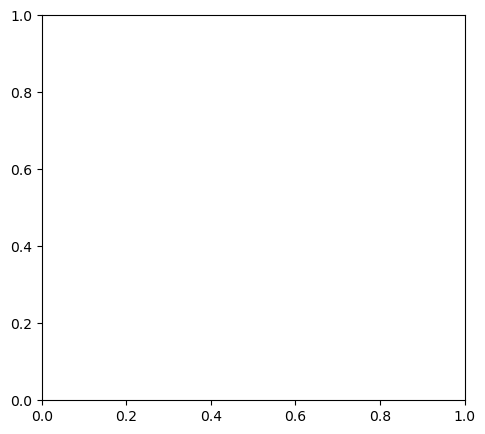

In [14]:
# Cell 7: Plot training metrics
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# Cell 8: Save the model
model.save('seitsemänveljestä_model.keras')
print("Model saved as 'seitsemänveljestä_model.keras'")

Model saved as 'seitsemänveljestä_model.keras'


In [1]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """Generate text based on a prompt with proper lowercase handling."""
    # Convert prompt to lowercase to match training data
    lowercase_prompt = prompt  #.lower()

    # Encode the prompt
    input_ids = sp.encode_as_ids(lowercase_prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

In [2]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import torch

audio_file = "../datasets/whisper/testi2.wav"

def transcribe_audio_with_whisper(audio_array, sr=16000, model_size="large"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model_name = f"openai/whisper-{model_size}"
    
    processor = WhisperProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)
    
    forced_decoder_ids = processor.get_decoder_prompt_ids(language="fi", task="transcribe")
    
    input_features = processor(
        audio_array, 
        sampling_rate=sr, 
        return_tensors="pt"
    ).input_features.to(device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids
        )
    
    transcription = processor.batch_decode(
        generated_ids, 
        skip_special_tokens=True
    )[0]
    
    return transcription


C:\Users\kisme\anaconda3\envs\keras\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\kisme\anaconda3\envs\keras\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Testataan ensin tekstin generointi default parametreilla, eli 100 tokenia ja lämpötila 1.0.

In [3]:
import librosa

# Cell 10: Generate sample text
prompts = [
    "Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää."
]


def generate_text_for_prompts(prompts, num_tokens, temperature):
    for prompt in prompts:
        print(f"\nPrompt: {prompt}")
        generated = generate_text(model, sp, prompt, num_tokens, temperature)
        print(generated)

y, sr = librosa.load(audio_file, sr=16000)
# large model
transcription = transcribe_audio_with_whisper(y, sr)
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=1.0)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Prompt: Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää.


NameError: name 'model' is not defined

In [ ]:
transcription = transcribe_audio_with_whisper(y, sr, model_size="medium")
print(transcription)

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

Muutetaan ensin lämpötilaa, mikä vaikuttaa tekstin satunnaisuuteen. Mitä pienempi lämpötila sitä loogisempaa teksti on, mutta myös vähemmän luovaa. Mitä suurempi lämpötila, sitä satunnaisempaa ja luovempaa teksti on, mutta myös vähemmän järkevää.


In [1]:
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=0.7)

NameError: name 'generate_text_for_prompts' is not defined

Kuten alhaalta näemme, lämpötilan laskeminen 0.2:een tekee tekstistä paljon järkevämpää ja vähemmän satunnaista. Tekstissä on kuitenkin paljon suoria kopioita alkuperäisestä tekstistä.

In [40]:
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=0.2)


Prompt:  Stefanos, mistä saimmekaan puuta? Saimme puuta Samulin mökin takaa.
Stefanos, mistä saimmekaan puuta? Saimme puuta Samulin mökin takaa. EERO. Hän on pyynnissä, ankarassa ajossa, ja Möl tietäin hallan sudentarhan ojankoon ja padassa kaksi tammipöytyriä, kauhan, seitsemän lusikkaa ja muita huoneessa tarpeellisia kaluja, kertoili sisarensa pojille tarinoita ja merkillisiä juuritall kappale kehräjälintuu. Näin vähänpä taivaan kevät. Rapustaen astui hän teimme Pojat, pojat ymmärtää korpin Juo, jota entinen Jukolan vanhasta Iloisessa huimauksessayvämme kulki kaunista, kädetjestä alas, ja muistelivat tässä Lyökääs, kun tahdon nyt kuorsaa kuin mies; mutta maatkoon siellä hän ympärilleen mar' oltta Maija. SIMEONI. muistellessani nurkkia, potkii tämä


Seuraavaksi testataan korkealla lämpötilalla.

In [ ]:
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=2.0)

Kokeillaan 200 tokenia, jotta saadaan enemmän tekstiä. Lämpötila on 1.0, joten teksti on melko satunnaista.

In [32]:
generate_text_for_prompts(prompts=prompts, num_tokens=150, temperature=1.0)


Prompt:  Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää?
Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää? Sen eteläisellä puolella teki. Ja niinpä jyrkeä henki Impivaaran koulupöydän ääressä vallitsi kauan, kunnes aika, mennessä muutaman päivän, lievitti jälleen Eeron äkeän mielen ja muodon. Niin harrastelivat veljekset ehtiäkseen lukemisen taitoon, ja edistyikin heidän työnsä, vaikka alussa sangen vitkaa, varsinkin Timolta ja Juhanilta. KAHDESTOISTA LUKU Kesä tuli ja työ vainiolla alkoi. Veljekset milloin kyntelivät ja äjestelivät peltoansa, milloin raivasivat niittua korvessa ja milloin taasen rakentelivat uutta omettaansa kumisevalle aholle. Vaikeaksi tuntui heille alussa tämä raatamisen järjestys; mutta, pakoittaen luontoansa, taisivat he viimein täyttää kaikki arkiopäivät aamusta iltaan. Ja niin valmistui heidän omettansa, heidän peltonsa muuttui hienoksi mul

Kokeillaan 200 tokenia, jotta saadaan enemmän tekstiä. Lämpötila on 0.7, joten teksti on melko satunnaista, mutta järkevämpää.

In [42]:
generate_text_for_prompts(prompts=prompts, num_tokens=200, temperature=0.7)


Prompt:  Stefanos, mistä saimmekaan puuta? Saimme puuta Samulin mökin takaa.
Stefanos, mistä saimmekaan puuta? Saimme puuta Samulin mökin takaa. Hän astui pihalle, ja koska lähestyi hän illan tullessa vaikeni ja vaipui lepoon. Kuin hauta niin äänetön ja kylmä oli yö, ja pellon povella makasi harmaa halla, hengittäen kuoloa kylmää. Varhain seuraavana aamuna astuivat veljekset pirtistänsä ulos ja katselivat kauhistuen hävitystä vainiolla. Ja valkeana, lakastuneena kajasti pian äsken viherjöitsevä laiho. Tuumiskelivat miehet mitä nyt tehdä ja mihin keinoon ryhtyä, ja harkitsivat parhaaksi, raivaten ja kaivellen perinpohjin kuivata Sompiosuo, josta he tiesivät hallan nousevan heidän pelloillensa. Niin he päättivät, ja möyräilivät ja kaivelivat sumuisessa suossa, kuluessa kuuman kesän, nähden usein mieltä synkistävää nälkää. Oli silloin työpäivä raskas; väsyneinä käyskelivät he kotiansa vasta auringon laskiessa, ja tuskan ja vaivan musta juonne ympäröitsi vaisun miehen huulet. Mutta syksyn

Kokeillaan 160 tokenia. Lämpötila on 0.7, syystä, että Kalevalan teksti on runollista ja sille täytyy antaa jotain tilaa luovuudelle. Teksti on kuitenkin edelleen järkevää ja loogista. 

In [33]:
generate_text_for_prompts(prompts=prompts, num_tokens=160, temperature=0.7)


Prompt:  Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää?
Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää? Sen tiedämme seisoivat veljekset, kolmen päivän kuluttua Eeron äkeä mieli oli vähän lievinnyt, antoi hän muristen ilmi kuinka Simeonin laita oli heidän palatessaan kaupungista. Olipa hän useinkin haastellut joistakin pienistä, tuumankorkeista äijistä, jotka, niinkuin hän lausuili, parveilivat tuhansittain hänen ympärillään. Niin kertoili


Nyt sen sijaan, että annamme promptiksi prompts listan, annamme sille valmiiksi luodun whisper transkription. Joka kutsuu funktion transcribe_audio_with_whisper, joka käyttää whisper mallia kääntääkseen äänitteen tekstiksi. 

In [15]:
generate_text_for_prompts(prompts=[transcription], num_tokens=160, temperature=0.7)


Prompt:  Mitä se Vesa vastas? Vastas mulle, mut ei se vastannu siihen heettisiä paskaa. Mihin se sit vastas? Oikeeseen kuulsein mitä mä laitoin sille että...
Mitä se Vesa vastas? Vastas mulle, mut ei se vastannu siihen heettisiä paskaa. Mihin se sit vastas? Oikeeseen kuulsein mitä mä laitoin sille että... elkeänne siniset koskee Tähtiä muuttui päästänne katsellen vakavanjainen ihmeellisen aivoni tämä tuomiopäivään rajanaapureille kehen sanoppas kalliolta melskeen pysyvä nuoli opetustansa liekkiuksensa alaspa elämää aattelen asiaansa yhä.. monenkin klo vastauksia korvi retkiä nauriin hän sauna näpäkkurin Pohjaanitä Hiiden tiuskeampi jäätynyt ehtoollinen loimotti rakkauden näinä juoksi tiesivätnitta kokeneet aittaansa jo olivat kamaralle omettaa tulisissa toivonäänä kuoleman temppelissä tähtäillen kieppasi veressä naureskelivat Tappelua kuultelee kaulaaHelvetti nousemassa yöksi myrskyisellä koto ään rouskunkunn menis petyit ilman Mustalaiset liekit muotoansakistyy pyhävaatte unohda hell

In [ ]:
# Cell 11: Load model (if you're starting a new session)
# Uncomment these lines to load a previously saved model
"""
# Load saved model
model = keras.models.load_model('kalevala_model.keras')

# Load SentencePiece tokenizer
sp = spm.SentencePieceProcessor()
sp.load('kalevala_sp.model')

# Test generation
prompt = "Mieleni minun tekevi"
generated = generate_text(model, sp, prompt, num_tokens=150, temperature=1.0)
print(generated)
"""